# Stage 1 — Dataset Inspection

**Project:** ResearchMate — Research Paper RAG Chatbot
**Goal of this notebook:** Load `train.csv` and understand its shape, columns, missing values, duplicates, abstract lengths, and topic-label distribution — *before* we design the RAG pipeline.

No LangChain, no embeddings, no vector store yet. This is pure pandas exploration.

**Before running:** upload `train.csv` to this Colab session (left sidebar → Files → upload), or mount Google Drive and update the path in Cell 1.


## Cell 1 — Load the dataset

Reads `train.csv` into a pandas DataFrame and shows its shape (rows, columns) plus the first few rows, so we can visually confirm the data loaded correctly.

In [3]:
import pandas as pd

df = pd.read_csv("train.csv")   # change path if using Google Drive, e.g. "/content/drive/MyDrive/.../train.csv"

print("Shape:", df.shape)
df.head()

Shape: (20972, 9)


,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


## Cell 2 — Column names and data types

We print the exact column names as Kaggle actually named them (spelling/casing can differ from documentation), plus each column's dtype and non-null count via `.info()`. Every later stage will reuse these exact names, so this is important to get right rather than assume.

In [4]:
print("Columns:", df.columns.tolist())
df.info()

Columns: ['ID', 'TITLE', 'ABSTRACT', 'Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


## Cell 3 — Missing values

Counts null/missing entries per column. If `ABSTRACT` (or `TITLE`) has missing values, we'll need to drop or handle those rows in Stage 2, since an empty abstract is useless for retrieval.

In [5]:
df.isnull().sum()

,0
ID,0
TITLE,0
ABSTRACT,0
Computer Science,0
Physics,0
Mathematics,0
Statistics,0
Quantitative Biology,0
Quantitative Finance,0


## Cell 4 — Duplicate IDs and duplicate text

Checks whether any `ID` values repeat (they shouldn't — IDs are meant to be unique), and whether any `TITLE` or `ABSTRACT` values repeat across rows (duplicate papers, or near-duplicates, can quietly hurt retrieval quality later).

This cell auto-detects the ID/title/abstract column names from what's actually in the file, so it won't break if the casing differs from what we expect.

In [6]:
# Auto-detect the likely ID / TITLE / ABSTRACT columns by matching common name variants
def find_col(possible_names, columns):
    for name in possible_names:
        for col in columns:
            if col.strip().lower() == name:
                return col
    return None

id_col = find_col(["id"], df.columns)
title_col = find_col(["title"], df.columns)
abstract_col = find_col(["abstract"], df.columns)

print("Detected ID column:", id_col)
print("Detected TITLE column:", title_col)
print("Detected ABSTRACT column:", abstract_col)

if id_col:
    print("Duplicate IDs:", df[id_col].duplicated().sum())
if title_col:
    print("Duplicate TITLEs:", df[title_col].duplicated().sum())
if abstract_col:
    print("Duplicate ABSTRACTs:", df[abstract_col].duplicated().sum())

Detected ID column: ID
Detected TITLE column: TITLE
Detected ABSTRACT column: ABSTRACT
Duplicate IDs: 0
Duplicate TITLEs: 0
Duplicate ABSTRACTs: 0


## Cell 5 — Abstract length distribution

Computes the word count of every abstract and shows summary statistics (`.describe()`) plus a histogram. Abstracts are typically short (a paragraph), which directly affects our text-splitting decision in Stage 4 — we may not need heavy chunking at all.

count    20972.000000
mean       148.404873
std         60.781306
min          1.000000
25%        104.000000
50%        145.000000
75%        190.000000
max        449.000000
Name: abstract_word_count, dtype: float64


<Axes: >

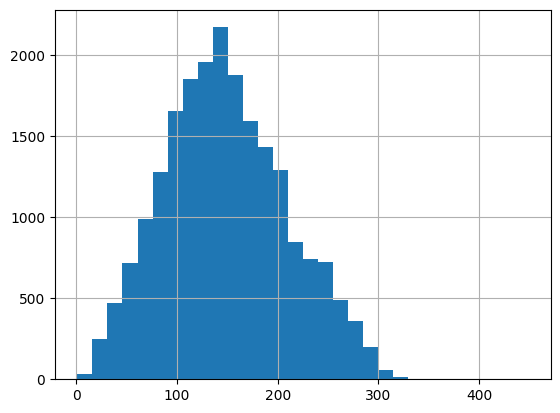

In [7]:
df["abstract_word_count"] = df[abstract_col].apply(lambda x: len(str(x).split()))

print(df["abstract_word_count"].describe())
df["abstract_word_count"].hist(bins=30)

## Cell 6 — Topic label distribution

This is the "robust" version: instead of hardcoding the 6 topic column names, we first auto-detect them as *whatever columns are left over* after removing ID/TITLE/ABSTRACT/abstract_word_count. This avoids errors if Kaggle's actual column names use different casing or underscores than we assumed.

We then print:
- how many papers belong to each topic
- how many papers have 1, 2, or more topics assigned (multi-label papers)

In [8]:
# Identify topic columns automatically: everything except id/title/abstract/word-count columns
known_non_topic_cols = {id_col, title_col, abstract_col, "abstract_word_count"}
topic_cols = [c for c in df.columns if c not in known_non_topic_cols]

print("Detected topic columns:", topic_cols)

# How many papers per topic
print("\nPapers per topic:")
print(df[topic_cols].sum())

# How many topics per paper (multi-label check)
df["num_topics"] = df[topic_cols].sum(axis=1)
print("\nNumber of topics assigned per paper:")
print(df["num_topics"].value_counts().sort_index())

Detected topic columns: ['Computer Science', 'Physics', 'Mathematics', 'Statistics', 'Quantitative Biology', 'Quantitative Finance']

Papers per topic:
Computer Science        8594
Physics                 6013
Mathematics             5618
Statistics              5206
Quantitative Biology     587
Quantitative Finance     249
dtype: int64

Number of topics assigned per paper:
num_topics
1    15928
2     4793
3      251
Name: count, dtype: int64


## What to check after running this notebook

- **Shape (Cell 1):** should be close to (20972, 9).
- **Columns (Cell 2):** note the *exact* names printed — we'll use these exact names in Stage 2 onward.
- **Missing values (Cell 3):** ideally all zero. If `ABSTRACT` has any nulls, we'll drop those rows next stage.
- **Duplicates (Cell 4):** duplicate IDs should be 0. Some duplicate titles/abstracts may exist — not necessarily a problem, just worth knowing.
- **Abstract length (Cell 5):** note the mean/median word count from `.describe()` — this decides our chunk size in Stage 4.
- **Topic distribution (Cell 6):** note which topics dominate (likely Computer Science) and how many papers have more than one topic.

Copy/paste (or screenshot) the outputs of Cells 1, 2, 3, 5, and 6 back into the chat — that's what we'll use to design Stage 2.